# UV extraction 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import pandas as pd
import re

In [2]:
ds = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
print(ds)

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.a

In [3]:
u_da = (
    ds.u.isel(s_rho=-1).reset_coords(
    drop=True).assign_coords(
    xi_u=ds.lon_rho.compute().values[0,:-1], 
    eta_rho=ds.lat_rho.compute().values[:,0]
    ).rename({'eta_rho': 'lat', 'xi_u': 'lon'}))

v_da = (
    ds.v.isel(s_rho=-1).reset_coords(
    drop=True).assign_coords(
    xi_rho=ds.lon_rho.compute().values[0,:], 
    eta_v=ds.lat_rho.compute().values[:-1,0]
    ).rename({'eta_v': 'lat', 'xi_rho': 'lon'}))

# 1) Build the 2D lat/lon grid of u
lon_u2d, lat_u2d = xr.broadcast(v_da['lon'], u_da['lat'])  # both (542, 601)

# 2) Interpolate v onto u's grid using real lat/lon coordinates
v = v_da.interp(lat=lat_u2d, lon=lon_u2d)
u = u_da.interp(lat=lat_u2d, lon=lon_u2d)
print(u.shape, v.shape)  # both (542, 602)

(1, 602, 542) (1, 602, 542)


## Loading Data

In [14]:
# ─── Helper functions ───────────────────────────────────────────

def compute_z_rho(ds):
    """Compute 3D z-depths at rho-points from CROCO vertical coords."""
    h   = ds.h.compute()
    hc  = float(ds.hc)
    Cs_r = ds.Cs_r.compute()
    Vtransform = int(ds.Vtransform)

    if Vtransform == 2:
        S     = (hc * ds.s_rho + h * Cs_r) / (hc + h)
        z_rho = S * h
    else:  # Vtransform == 1
        z_rho = hc * (ds.s_rho - Cs_r) + h * Cs_r
    return z_rho.compute()


def extract_at_mld(var_3d, z_3d, mld_2d):
    """
    Vectorized nearest-level extraction (replaces your MATLAB double loop).
    All inputs are numpy arrays.
      var_3d : (nz, ny, nx)
      z_3d   : (nz, ny, nx)  — negative depths
      mld_2d : (ny, nx)      — positive (hbl)
    Returns  : (ny, nx)
    """
    diff = np.abs(np.abs(z_3d) - mld_2d[np.newaxis, :, :])
    idx  = np.argmin(diff, axis=0)                          # (ny, nx)
    jj, ii = np.meshgrid(np.arange(idx.shape[0]),
                         np.arange(idx.shape[1]), indexing='ij')
    return var_3d[idx, jj, ii]


# ─── Main loader ────────────────────────────────────────────────

def load_mld_UV(path, time_val):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # 1) z on the rho-grid  (s_rho, eta_rho, xi_rho)
    z_rho = compute_z_rho(ds).values

    # 2) MLD = hbl on the rho-grid  (eta_rho, xi_rho), positive downward
    hbl = ds.hbl.squeeze("time", drop=True).compute().values

    # 3) Interpolate z and hbl onto the staggered U / V grids
    z_u   = 0.5 * (z_rho[:, :, :-1] + z_rho[:, :, 1:])   # → (s_rho, eta_rho, xi_u)
    hbl_u = 0.5 * (hbl[:, :-1]      + hbl[:, 1:])         # → (eta_rho, xi_u)

    z_v   = 0.5 * (z_rho[:, :-1, :] + z_rho[:, 1:, :])   # → (s_rho, eta_v, xi_rho)
    hbl_v = 0.5 * (hbl[:-1, :]      + hbl[1:, :])         # → (eta_v, xi_rho)

    # 4) 3D velocity fields as numpy
    u_3d = ds.u.squeeze("time", drop=True).compute().values  # (s_rho, eta_rho, xi_u)
    v_3d = ds.v.squeeze("time", drop=True).compute().values  # (s_rho, eta_v,  xi_rho)

    # 5) Extract at the nearest level to MLD  ← replaces your MATLAB loop
    u_mld = extract_at_mld(u_3d, z_u, hbl_u)   # (eta_rho, xi_u)
    v_mld = extract_at_mld(v_3d, z_v, hbl_v)   # (eta_v,  xi_rho)

    # 6) Wrap back to xarray (same coord logic as your surface code)
    lon_rho = ds.lon_rho.compute().values
    lat_rho = ds.lat_rho.compute().values

    u_da = (xr.DataArray(u_mld, dims=['eta_rho', 'xi_u'],
                         coords={'xi_u':    lon_rho[0, :-1],
                                 'eta_rho': lat_rho[:, 0]})
            .rename({'eta_rho': 'lat', 'xi_u': 'lon'})
            .expand_dims(time=[time_val]))

    v_da = (xr.DataArray(v_mld, dims=['eta_v', 'xi_rho'],
                         coords={'xi_rho': lon_rho[0, :],
                                 'eta_v':  lat_rho[:-1, 0]})
            .rename({'eta_v': 'lat', 'xi_rho': 'lon'})
            .expand_dims(time=[time_val]))

    # 7) Interpolate to common grid & build Dataset
    u = u_da.interp(lat=lat_u2d, lon=lon_u2d)
    v = v_da.interp(lat=lat_u2d, lon=lon_u2d)

    return xr.Dataset({"u": u, "v": v}, coords={"time": [time_val]})

In [5]:
from tqdm import tqdm
from pathlib import Path

files = sorted(Path("../../../NHCS/hincast_1980-2015/").glob("croco_avg_Y*M*.nc"))

# Extraer tiempo desde nombre de archivo
def extract_datetime_from_filename(path):
    match = re.search(r"Y(\d{4})M(\d{2})", path.name)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return np.datetime64(f"{year}-{month:02d}")
    else:
        raise ValueError(f"Fecha no encontrada en nombre: {path.name}")

# Lista de tiempos correctos
time_values = [extract_datetime_from_filename(f) for f in files]

In [16]:
UV_mld_list = [load_mld_UV(p, t) for p, t in tqdm(zip(files, time_values),
                                                    total=len(files))]
UV_mld_all = xr.concat(UV_mld_list, dim="time")


100%|███████████████████████████████████████████████████████████████████████| 432/432 [09:03<00:00,  1.26s/it]


In [22]:
# print(xr.open_dataset('UV_mld.nc'))

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lon: 602, lat: 542)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    u        (time, lon, lat) float64 1GB ...
    v        (time, lon, lat) float64 1GB ...


## From 0 to MLD

In [6]:
from numba import njit
import numpy as np
import xarray as xr

@njit
def extract_surface_to_mld(var_3d, z_3d, mld_depths, out_depths, out):
    """
    For each (j,i): extract variable at fixed `out_depths`
    using nearest sigma level, masked below MLD.
    var_3d:     (nz, ny, nx)
    z_3d:       (nz, ny, nx)   — negative depths
    mld_depths: (ny, nx)       — MLD in positive meters
    out_depths: (nd,)          — target depths in positive meters
    out:        (nd, ny, nx)   — pre-filled with NaN
    """
    nz, ny, nx = var_3d.shape
    nd = out_depths.shape[0]
    for j in range(ny):
        for i in range(nx):
            mld = mld_depths[j, i]
            z_col = z_3d[:, j, i]
            v_col = var_3d[:, j, i]
            for d in range(nd):
                if out_depths[d] > mld:
                    continue
                min_val = 1e30
                nearest_k = 0
                for k in range(nz):
                    diff = abs(abs(z_col[k]) - out_depths[d])
                    if diff < min_val:
                        min_val = diff
                        nearest_k = k
                out[d, j, i] = v_col[nearest_k]


def load_UV_surface_to_mld(path, time_val, depths):
    """
    Extract U and V on fixed depth levels from surface to MLD.
    Returns Dataset (time, depth, lat, lon) with NaN below MLD.
    """
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Sigma-level depths on rho-grid ---
    h      = ds['h'].values
    hc     = float(ds['hc'].values)
    Cs_r   = ds['Cs_r'].values
    s_rho  = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z_rho = (hc * s_rho[:, None, None]
                 + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z_rho = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
                 / (hc + h[None, :, :])
                 * h[None, :, :])

    # --- MLD ---
    hbl = ds['hbl'].isel(time=0).values  # (eta_rho, xi_rho), positive

    # --- Staggered grids: z and hbl on u/v points ---
    z_u   = 0.5 * (z_rho[:, :, :-1] + z_rho[:, :, 1:])
    hbl_u = 0.5 * (hbl[:, :-1]      + hbl[:, 1:])
    h_u   = 0.5 * (h[:, :-1]        + h[:, 1:])

    z_v   = 0.5 * (z_rho[:, :-1, :] + z_rho[:, 1:, :])
    hbl_v = 0.5 * (hbl[:-1, :]      + hbl[1:, :])
    h_v   = 0.5 * (h[:-1, :]        + h[1:, :])

    # --- 3D velocity fields ---
    u_3d = ds['u'].isel(time=0).values.astype(np.float64)   # (nz, eta_rho, xi_u)
    v_3d = ds['v'].isel(time=0).values.astype(np.float64)   # (nz, eta_v, xi_rho)

    out_depths = np.array(depths, dtype=np.float64)
    nd = len(depths)

    # --- Extract U ---
    ny_u, nx_u = hbl_u.shape
    out_u = np.full((nd, ny_u, nx_u), np.nan, dtype=np.float64)
    extract_surface_to_mld(u_3d, z_u.astype(np.float64),
                           hbl_u.astype(np.float64), out_depths, out_u)
    for k, d in enumerate(depths):
        out_u[k][h_u < d] = np.nan

    # --- Extract V ---
    ny_v, nx_v = hbl_v.shape
    out_v = np.full((nd, ny_v, nx_v), np.nan, dtype=np.float64)
    extract_surface_to_mld(v_3d, z_v.astype(np.float64),
                           hbl_v.astype(np.float64), out_depths, out_v)
    for k, d in enumerate(depths):
        out_v[k][h_v < d] = np.nan

    # --- Wrap as DataArrays ---
    lon_rho = ds['lon_rho'].compute().values
    lat_rho = ds['lat_rho'].compute().values

    u_da = xr.DataArray(
        out_u.astype(np.float32),
        dims=['depth', 'eta_rho', 'xi_u'],
        coords={'depth':   out_depths,
                'xi_u':    lon_rho[0, :-1],
                'eta_rho': lat_rho[:, 0]},
    ).rename({'eta_rho': 'lat', 'xi_u': 'lon'})

    v_da = xr.DataArray(
        out_v.astype(np.float32),
        dims=['depth', 'eta_v', 'xi_rho'],
        coords={'depth':   out_depths,
                'xi_rho':  lon_rho[0, :],
                'eta_v':   lat_rho[:-1, 0]},
    ).rename({'eta_v': 'lat', 'xi_rho': 'lon'})

    # --- Interpolate to common grid ---
    u = u_da.interp(lat=lat_u2d, lon=lon_u2d)
    v = v_da.interp(lat=lat_u2d, lon=lon_u2d)

    ds.close()

    UV = xr.Dataset(
        {"u": u, "v": v},
        attrs={'long_name': 'Velocities (surface to MLD)', 'units': 'm/s'}
    )
    return UV.expand_dims(time=[time_val])


# --- Depths to extract ---
depths = [0, 5] + list(range(10, 51, 5)) + list(range(60, 101, 10))

# --- Run ---
UV_surf_mld_list = [
    load_UV_surface_to_mld(f, t, depths)
    for f, t in tqdm(zip(files, time_values), total=len(files),
                     desc="UV surface→MLD")
]
UV_surf_mld_all = xr.concat(UV_surf_mld_list, dim="time")
print(UV_surf_mld_all)

UV surface→MLD: 100%|███████████████████████████████████████████████████████| 432/432 [10:22<00:00,  1.44s/it]


<xarray.Dataset> Size: 36GB
Dimensions:  (time: 432, depth: 16, lon: 602, lat: 542)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * depth    (depth) float64 128B 0.0 5.0 10.0 15.0 ... 70.0 80.0 90.0 100.0
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    u        (time, depth, lon, lat) float64 18GB 0.08685 0.08908 ... nan nan
    v        (time, depth, lon, lat) float64 18GB 0.02592 0.02564 ... nan nan
Attributes:
    long_name:  Velocities (surface to MLD)
    units:      m/s


In [7]:
UV_surf_mld_all

<xarray.Dataset> Size: 36GB
Dimensions:  (time: 432, depth: 16, lon: 602, lat: 542)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * depth    (depth) float64 128B 0.0 5.0 10.0 15.0 ... 70.0 80.0 90.0 100.0
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    u        (time, depth, lon, lat) float64 18GB 0.08685 0.08908 ... nan nan
    v        (time, depth, lon, lat) float64 18GB 0.02592 0.02564 ... nan nan
Attributes:
    long_name:  Velocities (surface to MLD)
    units:      m/s

In [8]:
depths_arr = UV_surf_mld_all.depth.values

# Layer thickness: distance between midpoints (same logic as np.gradient)
thickness = xr.DataArray(
    np.gradient(depths_arr),
    dims='depth',
    coords={'depth': depths_arr}
)

uv_wmean = UV_surf_mld_all.weighted(thickness).mean(dim='depth')
uv_wmean = uv_wmean.where(uv_wmean!=0)
uv_wmean

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lon: 602, lat: 542)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    u        (time, lon, lat) float64 1GB 0.08685 0.08908 0.09033 ... nan nan
    v        (time, lon, lat) float64 1GB 0.02592 0.02564 0.02268 ... nan nan

In [9]:
uv_wmean.to_netcdf('UV_0_mld.nc')

In [12]:
def seasonality(data):
    return data.groupby('time.season').mean(dim='time')

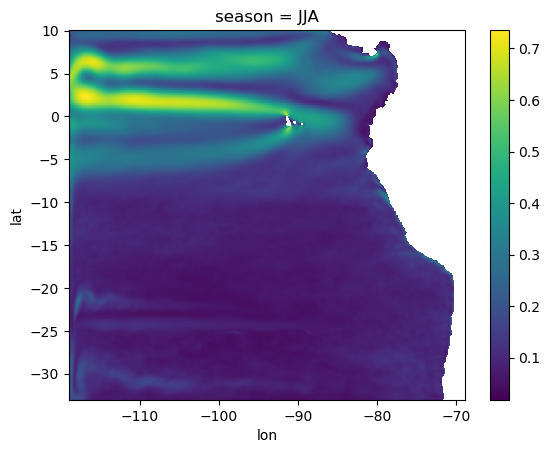

In [17]:
seasonality((uv_wmean.u**2 + uv_wmean.v**2)**0.5).isel(season=1).plot(y='lat')